In [3]:


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score,
                             accuracy_score)
import warnings
warnings.filterwarnings('ignore')



In [5]:
# ── Aesthetic setup ─────────────────────────────────────────────
PALETTE   = ["#2D6A4F", "#52B788", "#B7E4C7"]
ACCENT    = "#1B4332"
BG        = "#F8FAF9"
FONT_TITLE= 14
FONT_BODY = 11

sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG,
    "axes.edgecolor": "#CCCCCC", "grid.color": "#E0E0E0",
    "font.family": "DejaVu Sans"
})

# ── 1. Load & split data ───────────────────────────────────────
iris   = load_iris()
X, y   = iris.data, iris.target
labels = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)



In [7]:
# ── 2. Hyperparameter experiments ──────────────────────────────
experiments = {
    "Exp 1\n(1×16, lr=0.01)":   dict(hidden_layer_sizes=(16,),      learning_rate_init=0.01,  max_iter=500),
    "Exp 2\n(2×32, lr=0.01)":   dict(hidden_layer_sizes=(32,32),    learning_rate_init=0.01,  max_iter=500),
    "Exp 3\n(3×64, lr=0.001)":  dict(hidden_layer_sizes=(64,64,64), learning_rate_init=0.001, max_iter=500),
    "Exp 4\n(2×32, lr=0.001)":  dict(hidden_layer_sizes=(32,32),    learning_rate_init=0.001, max_iter=500),
    "Exp 5\n(1×128, lr=0.001)": dict(hidden_layer_sizes=(128,),     learning_rate_init=0.001, max_iter=500),
}

results = {}
for name, params in experiments.items():
    clf = MLPClassifier(random_state=42, **params)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    results[name] = {
        "clf": clf, "preds": preds,
        "acc": accuracy_score(y_test, preds),
        "prec": precision_score(y_test, preds, average="weighted"),
        "rec":  recall_score(y_test, preds, average="weighted"),
        "f1":   f1_score(y_test, preds, average="weighted"),
    }



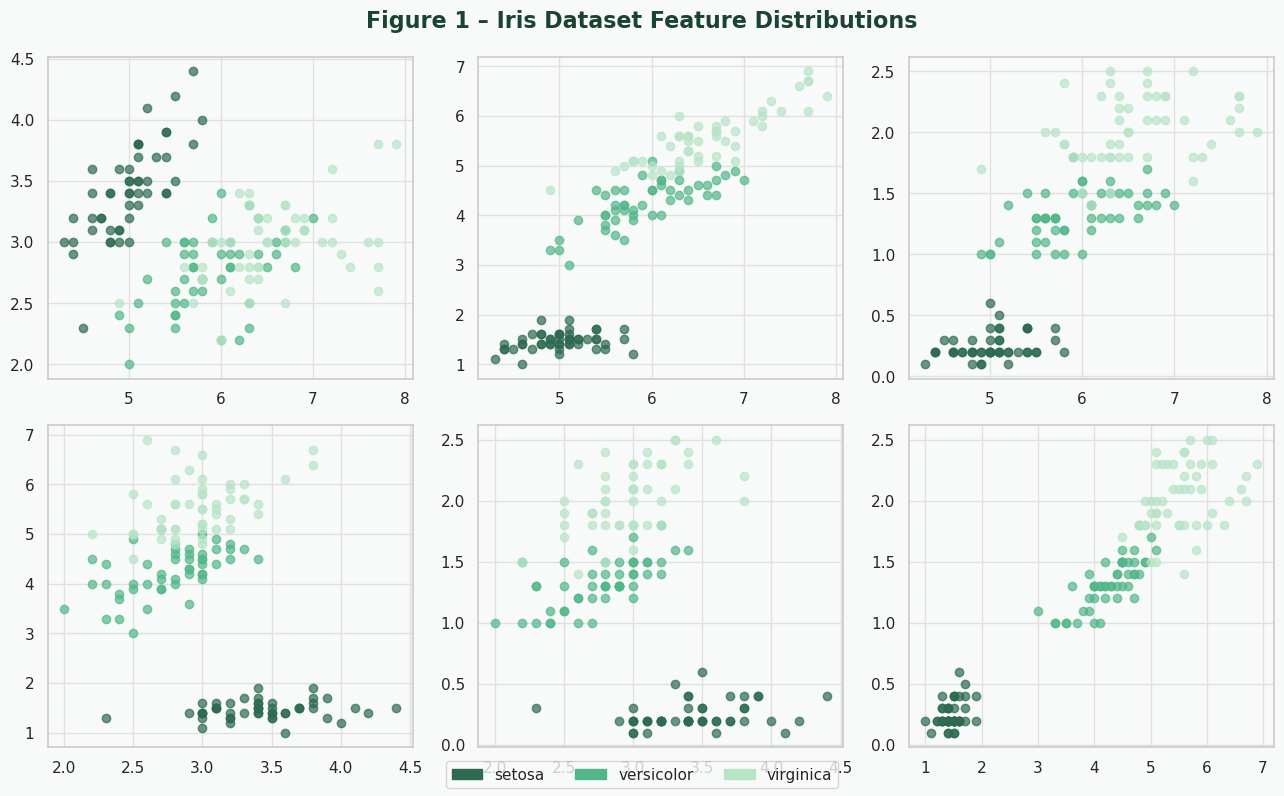

In [9]:
# ── 3. Best model ──────────────────────────────────────────────
best_key = max(results, key=lambda k: results[k]["f1"])
best     = results[best_key]
best_clf = best["clf"]
best_pred= best["preds"]

# ── FIGURE 1 ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
fig.suptitle("Figure 1 – Iris Dataset Feature Distributions", fontsize=FONT_TITLE+2, fontweight="bold", color=ACCENT)

feature_names = iris.feature_names
pairs = [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]

for ax, (i, j) in zip(axes.flat, pairs):
    for cls, col, lbl in zip(range(3), PALETTE, labels):
        mask = y == cls
        ax.scatter(X[mask,i], X[mask,j], c=col, label=lbl, alpha=0.7)

handles = [mpatches.Patch(color=c, label=l) for c, l in zip(PALETTE, labels)]
fig.legend(handles=handles, loc="lower center", ncol=3)

plt.tight_layout()
plt.savefig("fig1_dataset.png")
plt.show()
plt.close()



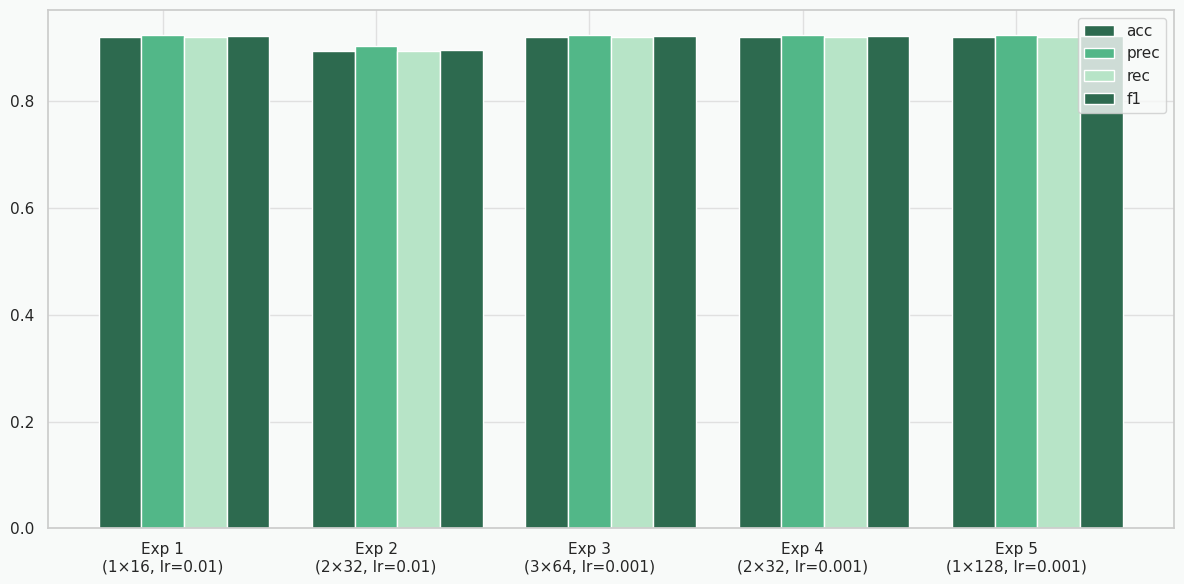

In [11]:
# ── FIGURE 2 ───────────────────────────────────────────────────
metrics = ["acc","prec","rec","f1"]
names = list(results.keys())
x = np.arange(len(names))
width = 0.2

fig, ax = plt.subplots(figsize=(12,6))
for i, m in enumerate(metrics):
    vals = [results[k][m] for k in names]
    ax.bar(x+i*width, vals, width, label=m)

ax.set_xticks(x + width)
ax.set_xticklabels(names)
ax.legend()

plt.tight_layout()
plt.savefig("fig2_hyperparams.png")
plt.show()
plt.close()



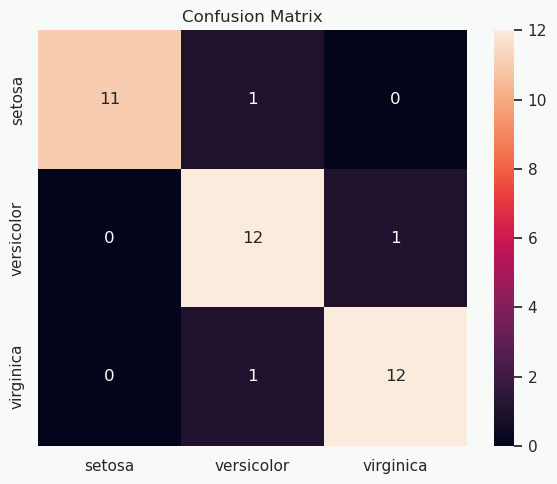

In [13]:
# ── FIGURE 3 ───────────────────────────────────────────────────
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("fig3_confusion.png")
plt.show()
plt.close()



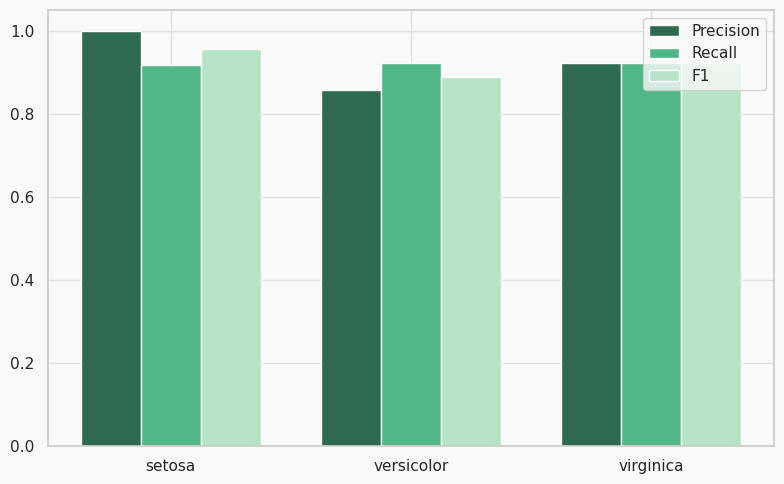

In [15]:
# ── FIGURE 4 ───────────────────────────────────────────────────
prec = precision_score(y_test, best_pred, average=None)
rec  = recall_score(y_test, best_pred, average=None)
f1   = f1_score(y_test, best_pred, average=None)

x = np.arange(3)
w = 0.25

plt.figure(figsize=(8,5))
plt.bar(x-w, prec, w, label="Precision")
plt.bar(x,   rec,  w, label="Recall")
plt.bar(x+w, f1,   w, label="F1")

plt.xticks(x, labels)
plt.legend()

plt.tight_layout()
plt.savefig("fig4_perclass.png")
plt.show()
plt.close()



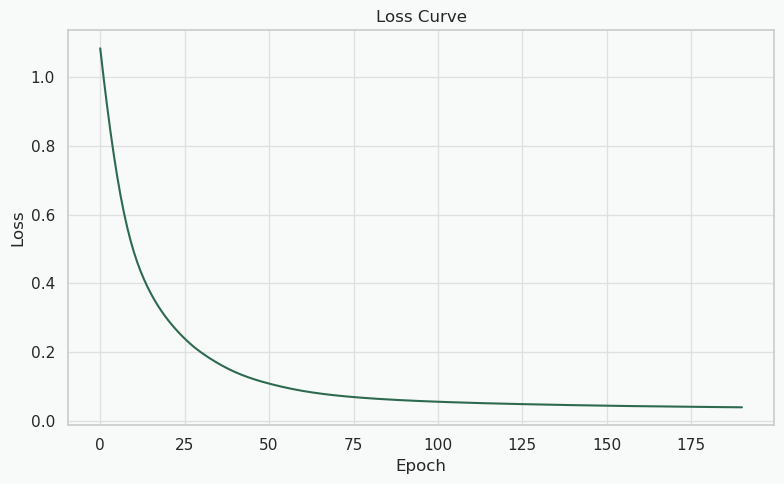

In [17]:
# ── FIGURE 5 ───────────────────────────────────────────────────
plt.figure(figsize=(8,5))
plt.plot(best_clf.loss_curve_)

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.tight_layout()
plt.savefig("fig5_loss.png")
plt.show()
plt.close()



In [19]:
# ── SUMMARY ────────────────────────────────────────────────────
print("\nBest Model:", best_key)
print("Accuracy:", best['acc'])
print("Precision:", best['prec'])
print("Recall:", best['rec'])
print("F1:", best['f1'])

print("\nClassification Report:\n")
print(classification_report(y_test, best_pred))


Best Model: Exp 1
(1×16, lr=0.01)
Accuracy: 0.9210526315789473
Precision: 0.9248120300751879
Recall: 0.9210526315789473
F1: 0.9219425375031783

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.86      0.92      0.89        13
           2       0.92      0.92      0.92        13

    accuracy                           0.92        38
   macro avg       0.93      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38

